## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL: https://arpitbajpai.weebly.com/seizure-detection-with-a-classifier.html


Arpit Bajpai
Full Time
TBA
Rafael


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn import svm

Importing data and doing some basic exploration. 

In [2]:
df = pd.read_csv('epilipsy.csv')
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [3]:
df=df.drop('Unnamed: 0', axis=1)
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


In [5]:
df.isna().sum().head()

X1    0
X2    0
X3    0
X4    0
X5    0
dtype: int64

In [6]:
unscaled_X= df.drop(['y'], axis=1)
unscaled_X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,...,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,...,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,10,4,2,-12,-32,-41,-65,-83,-89,-73


In [8]:
df1 = pd.read_csv('epilipsy.csv')
df1=df1.drop('Unnamed: 0', axis=1)
df1.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000011D4AFE3EB8>,
      dtype=object)

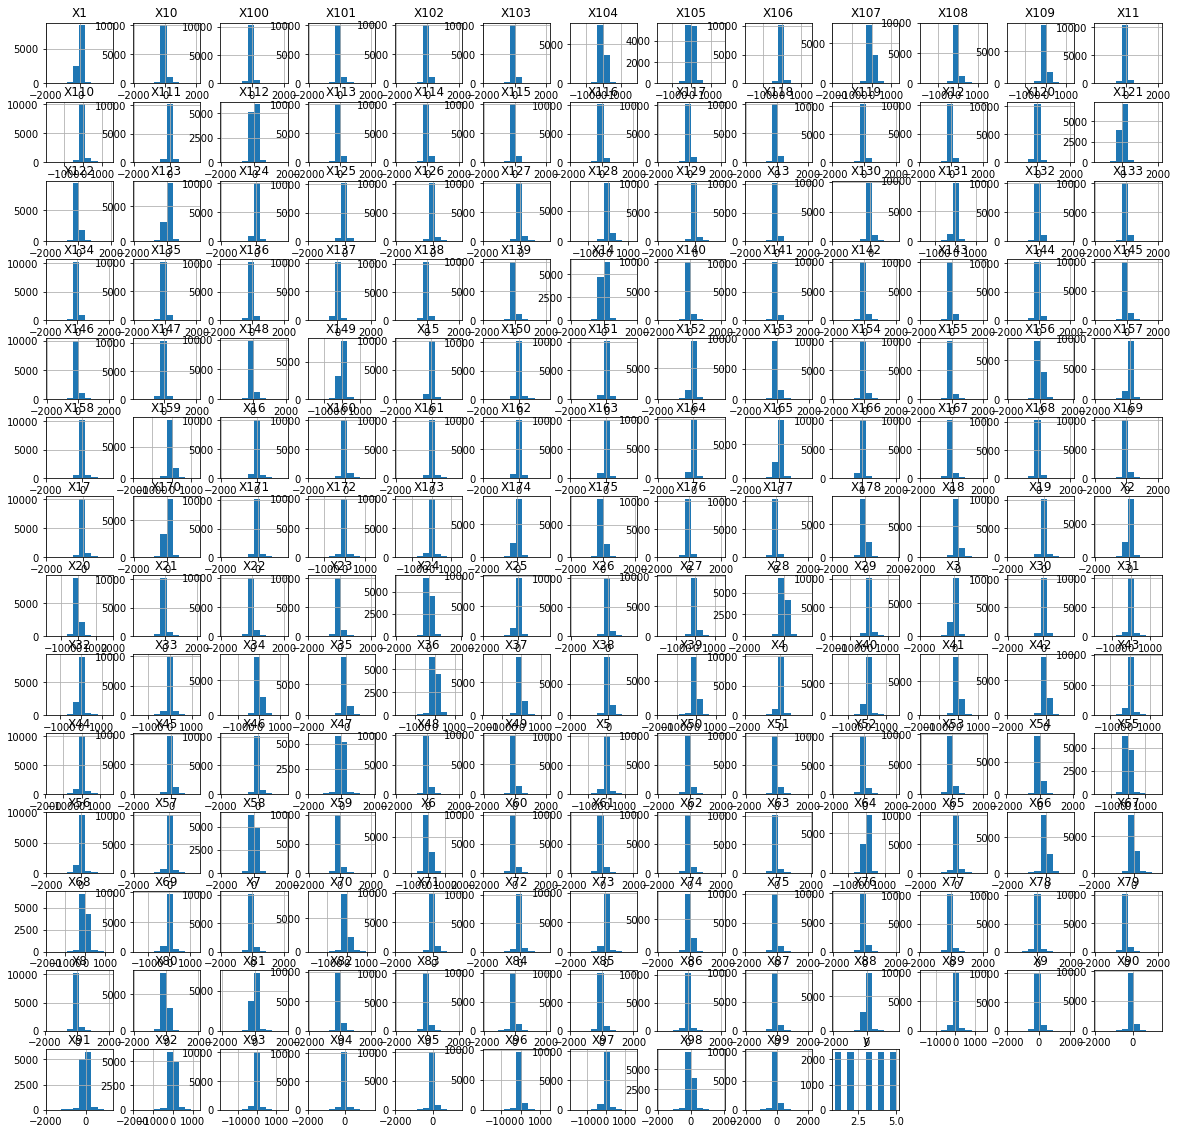

In [9]:
df1.hist(figsize=(20,20))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000011D4FFDAB00>,
      dtype=object)

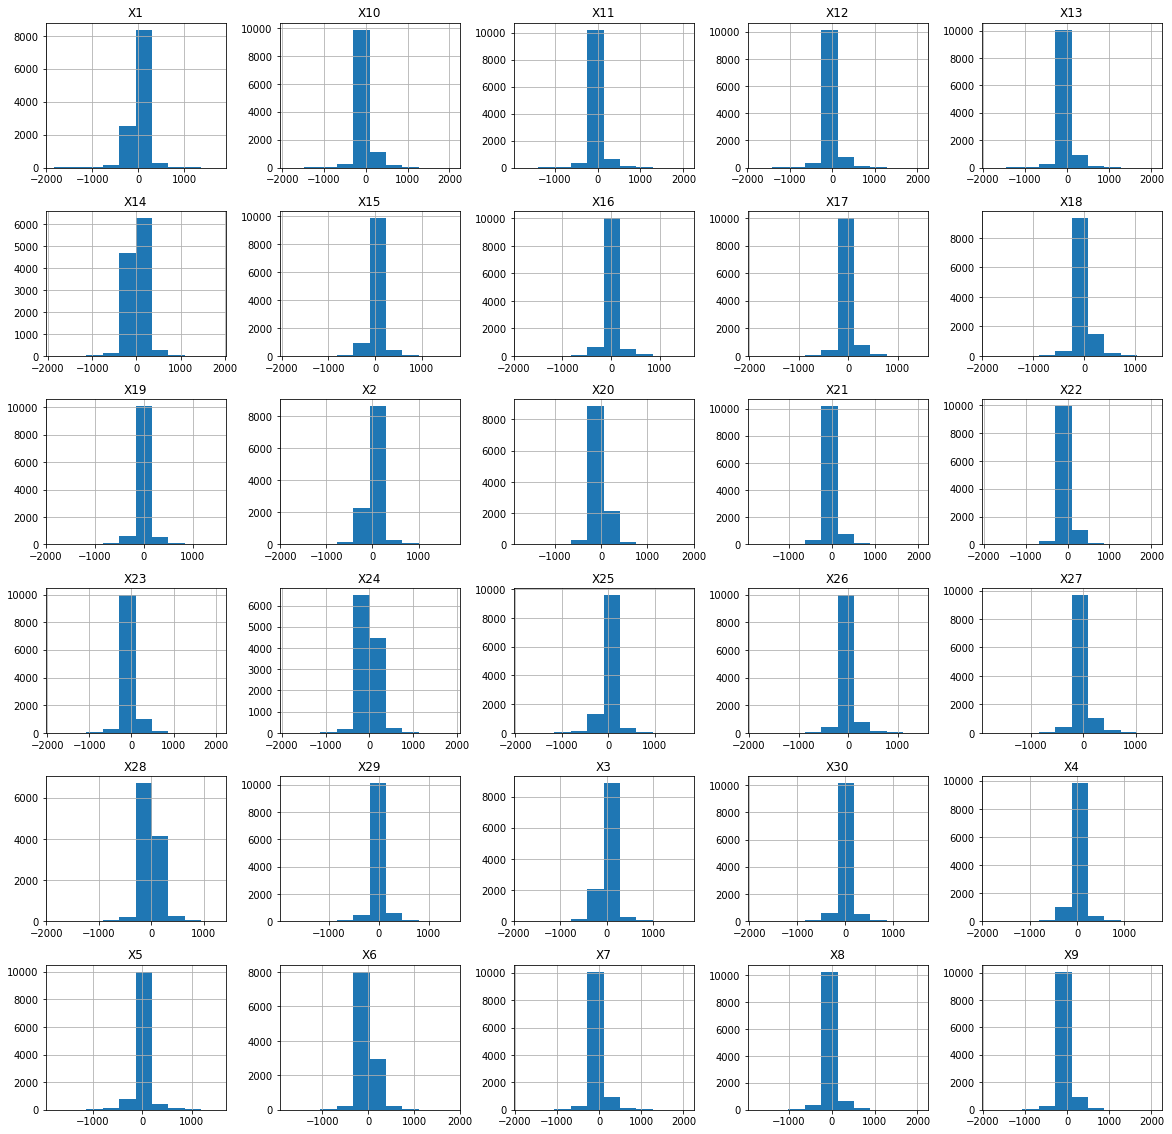

In [10]:
df1.loc[:,'X1':'X30'].hist(figsize=(20,20))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000011D513F4080>,
      dtype=object)

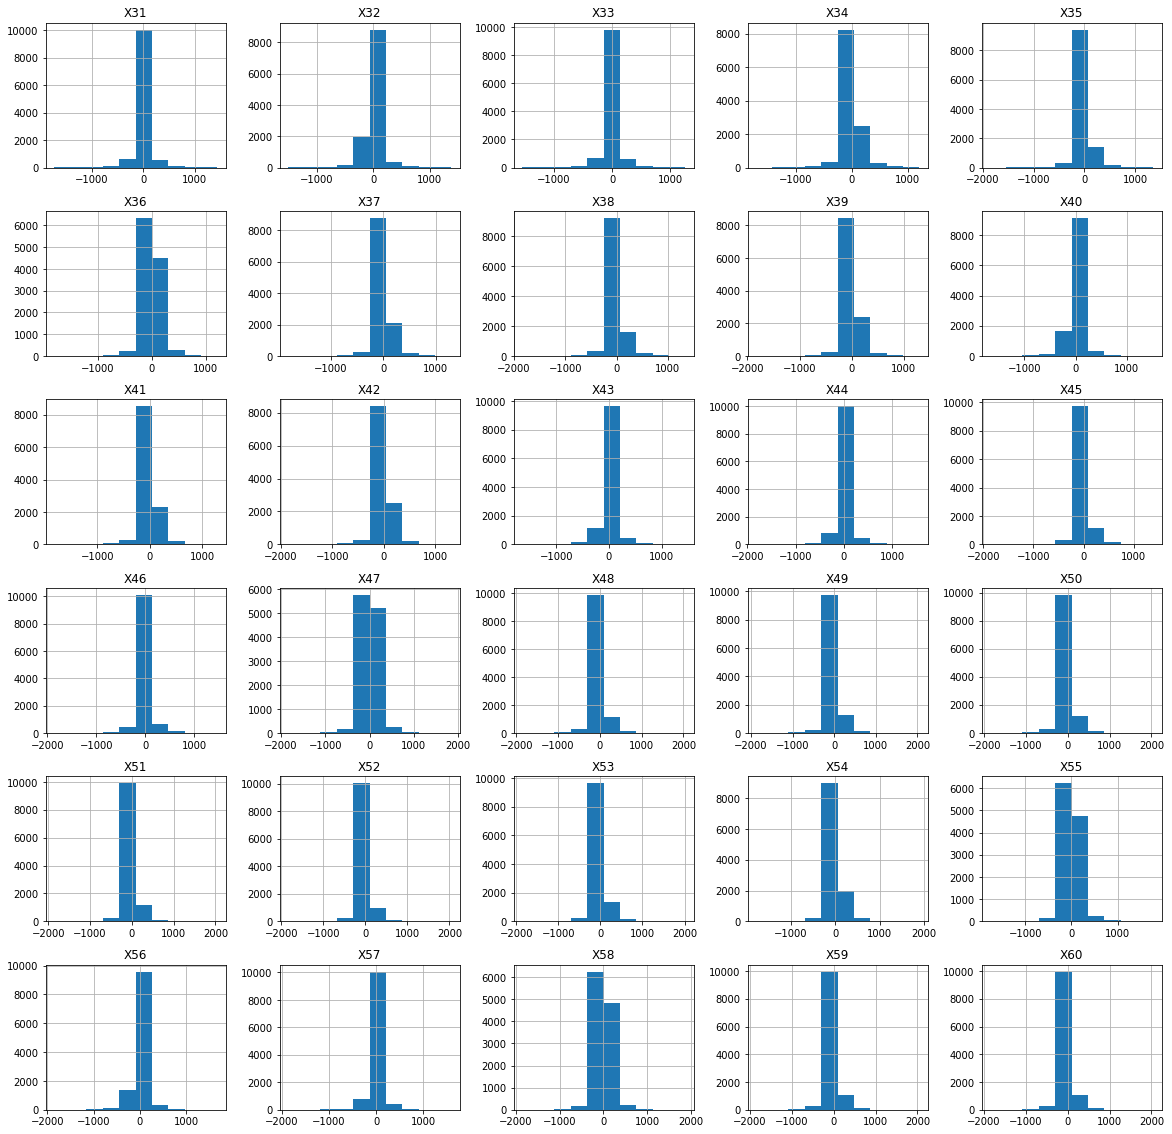

In [11]:
df1.loc[:,'X31':'X60'].hist(figsize=(20,20))

Almost all the data points appear to be centered closely around the mean. 

In [12]:
y = df['y']
y.head()

0    4
1    1
2    5
3    5
4    5
Name: y, dtype: int64

We have a range of values from 1 to 5 in our target value but we're only interested in 0 an 1 because they represent not having a seizure and having a seizure so let's replace everything that is not a 1 in our dataset with a zero to signify no seizure. 

In [14]:
for i in range(0, len(y)):
    if y[i]!= 1:
        y[i]=0
        

Let's scale our data to make it a bit more ML friendly. 

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X= scaler.fit_transform(unscaled_X)

C:\Users\xxtur\Anaconda3\envs\learn-env\lib\site-packages\sklearn\preprocessing\data.py:617: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\xxtur\Anaconda3\envs\learn-env\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


In [15]:
X

array([[ 0.88505134,  1.20992878,  1.46276429, ..., -0.63414367,
        -0.43329036, -0.23539922],
       [ 2.40057718,  2.36619038,  2.23944096, ...,  1.02342937,
         0.95424076,  0.85653664],
       [-0.12328657, -0.16915405, -0.22513147, ..., -0.13687176,
        -0.13859348, -0.14440456],
       ...,
       [ 0.1544592 ,  0.10184476, -0.01720228, ...,  0.0657205 ,
         0.07015014,  0.02545213],
       [-0.17159018, -0.08484331,  0.00725997, ...,  0.49546166,
         0.43852123,  0.40762968],
       [ 0.24502848,  0.31262161,  0.41088722, ...,  0.0657205 ,
         0.08856869,  0.19530882]])

Let's split our data 

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.25)

In [22]:
X1_train, X2_test, y1_train, y2_test = train_test_split(X,y ,test_size=.25)

In [23]:
from sklearn.preprocessing import LabelEncoder
labelencoder_Y = LabelEncoder()
y=labelencoder_Y.fit_transform(y)

In [24]:
y

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

Let's run a simple Logistic Regression 

In [25]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

C:\Users\xxtur\Anaconda3\envs\learn-env\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=0, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [26]:
preds = classifier.predict(X_test)

Before we can see our results, lets make a program to visualize our confusion_matrix

In [27]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, preds)

In [28]:
def show_cf(y_true, y_pred, class_names=None, model_name=None):
    cf = confusion_matrix(y_true, y_pred)
    plt.imshow(cf, cmap=plt.cm.Blues)
    
    if model_name:
        plt.title("Confusion Matrix: {}".format(model_name))
    else:
        plt.title("Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    class_names = set(y_true)
    tick_marks = np.arange(len(class_names))
    if class_names:
        plt.xticks(tick_marks, class_names)
        plt.yticks(tick_marks, class_names)
    
    thresh = cf.max() / 2.
    
    for i, j in itertools.product(range(cf.shape[0]), range(cf.shape[1])):
        plt.text(j, i, cf[i, j], horizontalalignment='center', color='white' if cf[i, j] > thresh else 'black')

    plt.colorbar()

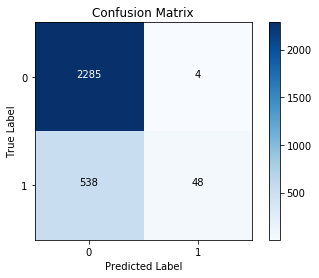

In [29]:
show_cf(y_test, preds)

We seem to be able to predict a non seizure pretty effectively but seizure prediction, our main goal is very poor, we must find a better model than this!. 

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [31]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      2289
           1       0.92      0.08      0.15       586

   micro avg       0.81      0.81      0.81      2875
   macro avg       0.87      0.54      0.52      2875
weighted avg       0.83      0.81      0.74      2875



In [32]:
print(accuracy_score(y_test, preds))

0.8114782608695652


Let's try creating a Decision Tree Classifier and see if it serves us any better. 

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
tree_clf = DecisionTreeClassifier(criterion = 'gini', max_depth=5)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=5,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [34]:
tree_pred = tree_clf.predict(X_test)

In [35]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      2289
           1       0.87      0.68      0.76       586

   micro avg       0.91      0.91      0.91      2875
   macro avg       0.89      0.83      0.85      2875
weighted avg       0.91      0.91      0.91      2875



This one seems to be able to predict the seizures much better and the accuracy score apppears to increase significantly as well. 

In [36]:
print(accuracy_score(y_test, tree_pred))

0.9130434782608695


In [37]:
from sklearn.model_selection import cross_val_score

In [38]:
dt_cv_score = cross_val_score(tree_clf, X_test, y_test, cv=5)
mean_dt_cv = np.mean(dt_cv_score)
mean_dt_cv

0.8973887584372738

In [39]:
unscaled_X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,...,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,...,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,10,4,2,-12,-32,-41,-65,-83,-89,-73


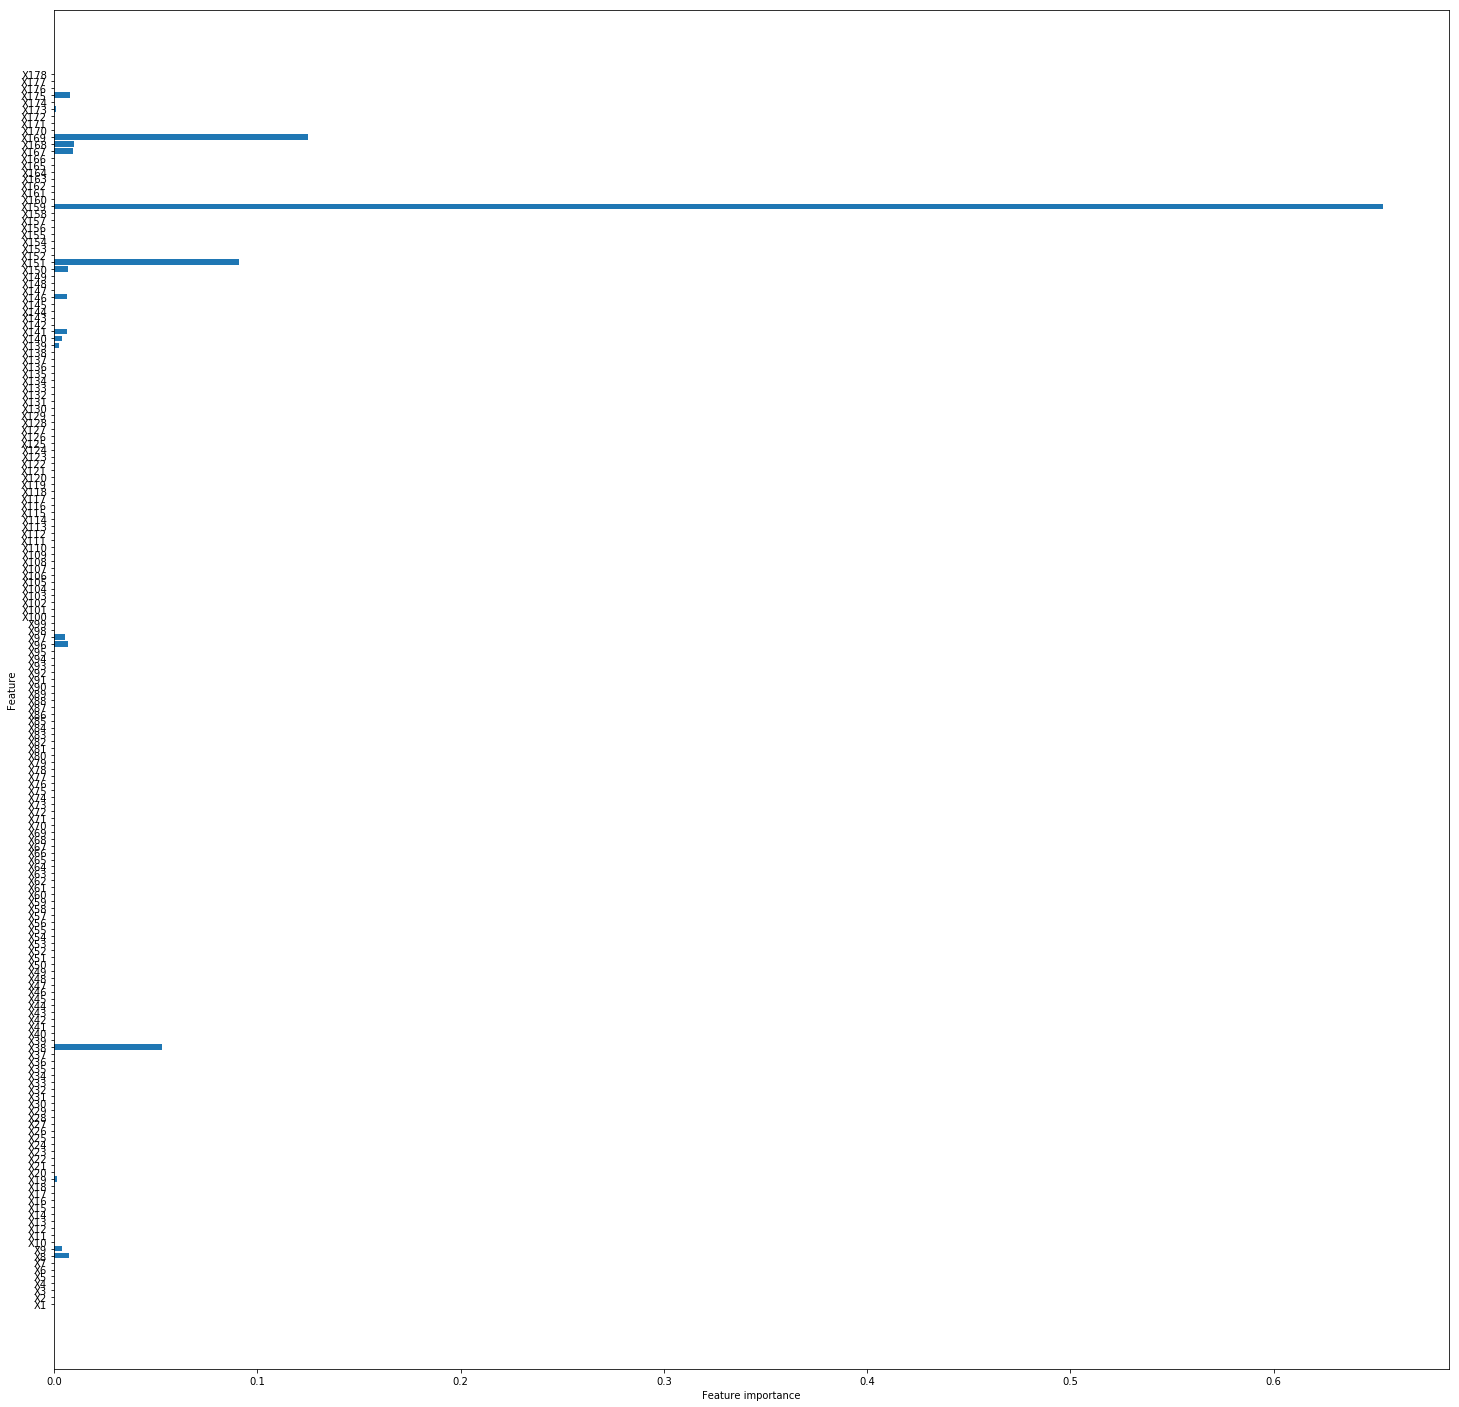

In [40]:
def plot_feature_importances(model):
    n_features = X_train.shape[1]
    plt.figure(figsize=(25,25))
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), unscaled_X.columns.values) 
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")

plot_feature_importances(tree_clf)

In [41]:
tree_pred = tree_clf.predict(X_test)
print(confusion_matrix(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

[[2228   61]
 [ 189  397]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      2289
           1       0.87      0.68      0.76       586

   micro avg       0.91      0.91      0.91      2875
   macro avg       0.89      0.83      0.85      2875
weighted avg       0.91      0.91      0.91      2875



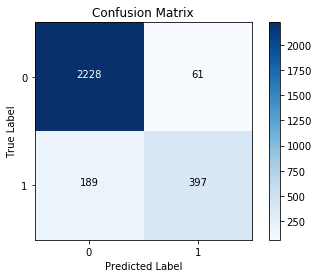

In [45]:
show_cf(y_test, tree_pred)

In [46]:
tree_clf.score(X_test, y_test)

0.9130434782608695

Let's add Grid Search to our model. 

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6]
}

In [49]:
dt_grid_search = GridSearchCV(tree_clf, dt_param_grid, cv=3, return_train_score=True)
dt_grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=5,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'criterion': ['gini', 'entropy'], 'max_depth': [None, 2, 3, 4, 5, 6], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 3, 4, 5, 6]},
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring=None, verbose=0)

In [50]:
dt_gs_training_score = np.mean(dt_grid_search.cv_results_['mean_train_score'])
dt_gs_testing_score = dt_grid_search.score(X_test, y_test)

print("Mean Training Score: {:.4}%".format(dt_gs_training_score * 100))
print("Mean Testing Score: {:.4}%".format(dt_gs_testing_score * 100))
print("Best Parameter Combination Found During Grid Search:")
dt_grid_search.best_params_

Mean Training Score: 93.64%
Mean Testing Score: 93.98%
Best Parameter Combination Found During Grid Search:


{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 5,
 'min_samples_split': 10}

In [51]:
tree_clf_grid = DecisionTreeClassifier(criterion = 'gini', max_depth=None, min_samples_leaf = 3, min_samples_split = 10)
tree_clf_grid.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=3, min_samples_split=10,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [52]:
grid_preds = tree_clf_grid.predict(X_test)

In [53]:
print(confusion_matrix(y_test, grid_preds))
print(classification_report(y_test, grid_preds))

[[2215   74]
 [ 111  475]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2289
           1       0.87      0.81      0.84       586

   micro avg       0.94      0.94      0.94      2875
   macro avg       0.91      0.89      0.90      2875
weighted avg       0.93      0.94      0.93      2875



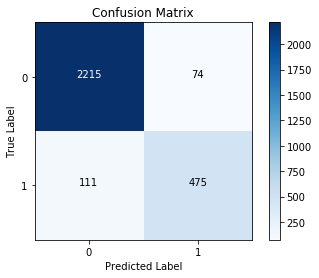

In [55]:
show_cf(y_test, grid_preds)

Our Recall and precision are increasing significantly. Let's make a bagging tree classifier.

In [56]:
accuracy_score(y_test, grid_preds)

0.9356521739130435

In [57]:
dt_cv_score = cross_val_score(tree_clf_grid, X_test, y_test, cv=3)
mean_dt_cv = np.mean(dt_cv_score)
mean_dt_cv

0.9213904387471582

In [58]:
bagged_tree =  BaggingClassifier(DecisionTreeClassifier(criterion='gini', max_depth=5), n_estimators=20)
bagged_tree.fit(X_train, y_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=5,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best'),
         bootstrap=True, bootstrap_features=False, max_features=1.0,
         max_samples=1.0, n_estimators=20, n_jobs=None, oob_score=False,
         random_state=None, verbose=0, warm_start=False)

In [59]:
bagged_pred = bagged_tree.predict(X_test)

In [60]:
accuracy_score(y_test, bagged_pred)

0.9339130434782609

In [61]:
print(confusion_matrix(y_test, bagged_pred))
print(classification_report(y_test, bagged_pred))

[[2270   19]
 [ 171  415]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2289
           1       0.96      0.71      0.81       586

   micro avg       0.93      0.93      0.93      2875
   macro avg       0.94      0.85      0.89      2875
weighted avg       0.94      0.93      0.93      2875



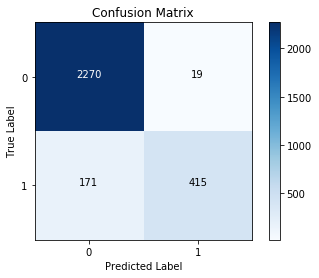

In [62]:
show_cf(y_test, bagged_pred)

All of our main values have increased significantly, but recall is still not where we want it to be. Let's try a random forest classifier. 

In [63]:
forest = RandomForestClassifier(n_estimators=100, max_depth=5)
forest.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=5, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=None,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False)

In [64]:
forest.score(X_train, y_train)

0.9536231884057971

In [65]:
forest.score(X_test, y_test)

0.945391304347826

In [66]:
f_pred =forest.predict(X_test)

In [67]:
print(accuracy_score(f_pred, y_test))
print(confusion_matrix(y_test, f_pred))
print(classification_report(y_test, f_pred))

0.945391304347826
[[2277   12]
 [ 145  441]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2289
           1       0.97      0.75      0.85       586

   micro avg       0.95      0.95      0.95      2875
   macro avg       0.96      0.87      0.91      2875
weighted avg       0.95      0.95      0.94      2875



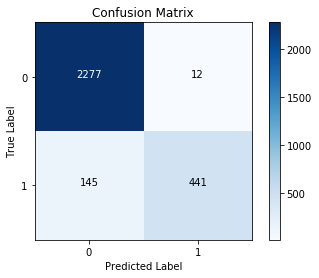

In [68]:
show_cf(y_test, f_pred)

Looks like we still nee to improve our predictor. We're still missing lots of siezures. Lets do Random Forest With Grid Search

In [69]:
mean_rf_cv_score = np.mean(cross_val_score(forest, X_test, y_test, cv=3))

print("Mean Cross Validation Score for Random Forest Classifier: {:.4}%".format(mean_rf_cv_score * 100))

Mean Cross Validation Score for Random Forest Classifier: 94.3%


In [70]:
rf_param_grid = {
    'n_estimators': [10,30,100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 6, 10],
    'min_samples_split': [5,10],
    'min_samples_leaf':[3,6]
}

In [71]:
import time
start = time.time()
rf_grid_search =GridSearchCV(forest, rf_param_grid, cv=3)
rf_grid_search.fit(X_test, y_test)

print("Testing Accuracy: {:.4}%".format(rf_grid_search.best_score_ * 100))
print("Total Runtime for Grid Search on Random Forest Classifier: {:.4} seconds".format(time.time() - start))
print("")
print("Optimal Parameters: {}".format(rf_grid_search.best_params_))

Testing Accuracy: 96.07%
Total Runtime for Grid Search on Random Forest Classifier: 115.6 seconds

Optimal Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 30}


In [72]:
grid_forest = RandomForestClassifier(criterion = 'gini', max_depth = None,min_samples_leaf=3, min_samples_split = 10, n_estimators=100)
grid_forest.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=3, min_samples_split=10,
            min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=None,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False)

In [73]:
g_f_pred = grid_forest.predict(X_test)

In [74]:
print(accuracy_score(g_f_pred, y_test))
print(confusion_matrix(y_test, g_f_pred))
print(classification_report(y_test, g_f_pred))

0.9735652173913043
[[2255   34]
 [  42  544]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2289
           1       0.94      0.93      0.93       586

   micro avg       0.97      0.97      0.97      2875
   macro avg       0.96      0.96      0.96      2875
weighted avg       0.97      0.97      0.97      2875



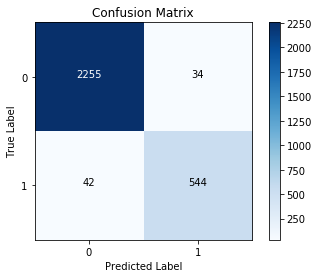

In [75]:
show_cf(y_test, g_f_pred)

This predictor is much more accurate with, grid forest, lets try to tune our parameters to work even bettter. 

In [76]:
from sklearn.cluster import KMeans

In [78]:
k_means_2 = KMeans(n_clusters=2).fit(X)
k_means_3 = KMeans(n_clusters=3).fit(X)
k_means_4 = KMeans(n_clusters=4).fit(X)
k_means_5 = KMeans(n_clusters=5).fit(X)
k_means_6 = KMeans(n_clusters=6).fit(X)
k_means_7 = KMeans(n_clusters=7).fit(X)

k_list = [k_means_2,k_means_3,k_means_4,k_means_5,k_means_6,k_means_7]

In [79]:
from sklearn.metrics import calinski_harabaz_score

In [80]:
CH_score = []
for i in k_list:
    label = i.labels_
    print(calinski_harabaz_score(X, label))
    CH_score.append(calinski_harabaz_score(X, label))


267.6380119917128
261.7424665216642
254.42443372218966
243.58781188436686
234.1635072698116
224.9581485728623


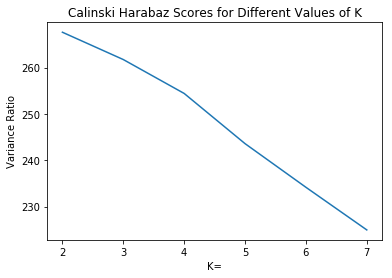

In [81]:
plt.plot([2,3, 4, 5, 6, 7], CH_score)
plt.xticks([2,3,4,5,6,7])
plt.title("Calinski Harabaz Scores for Different Values of K")
plt.ylabel("Variance Ratio")
plt.xlabel("K=")
plt.show()

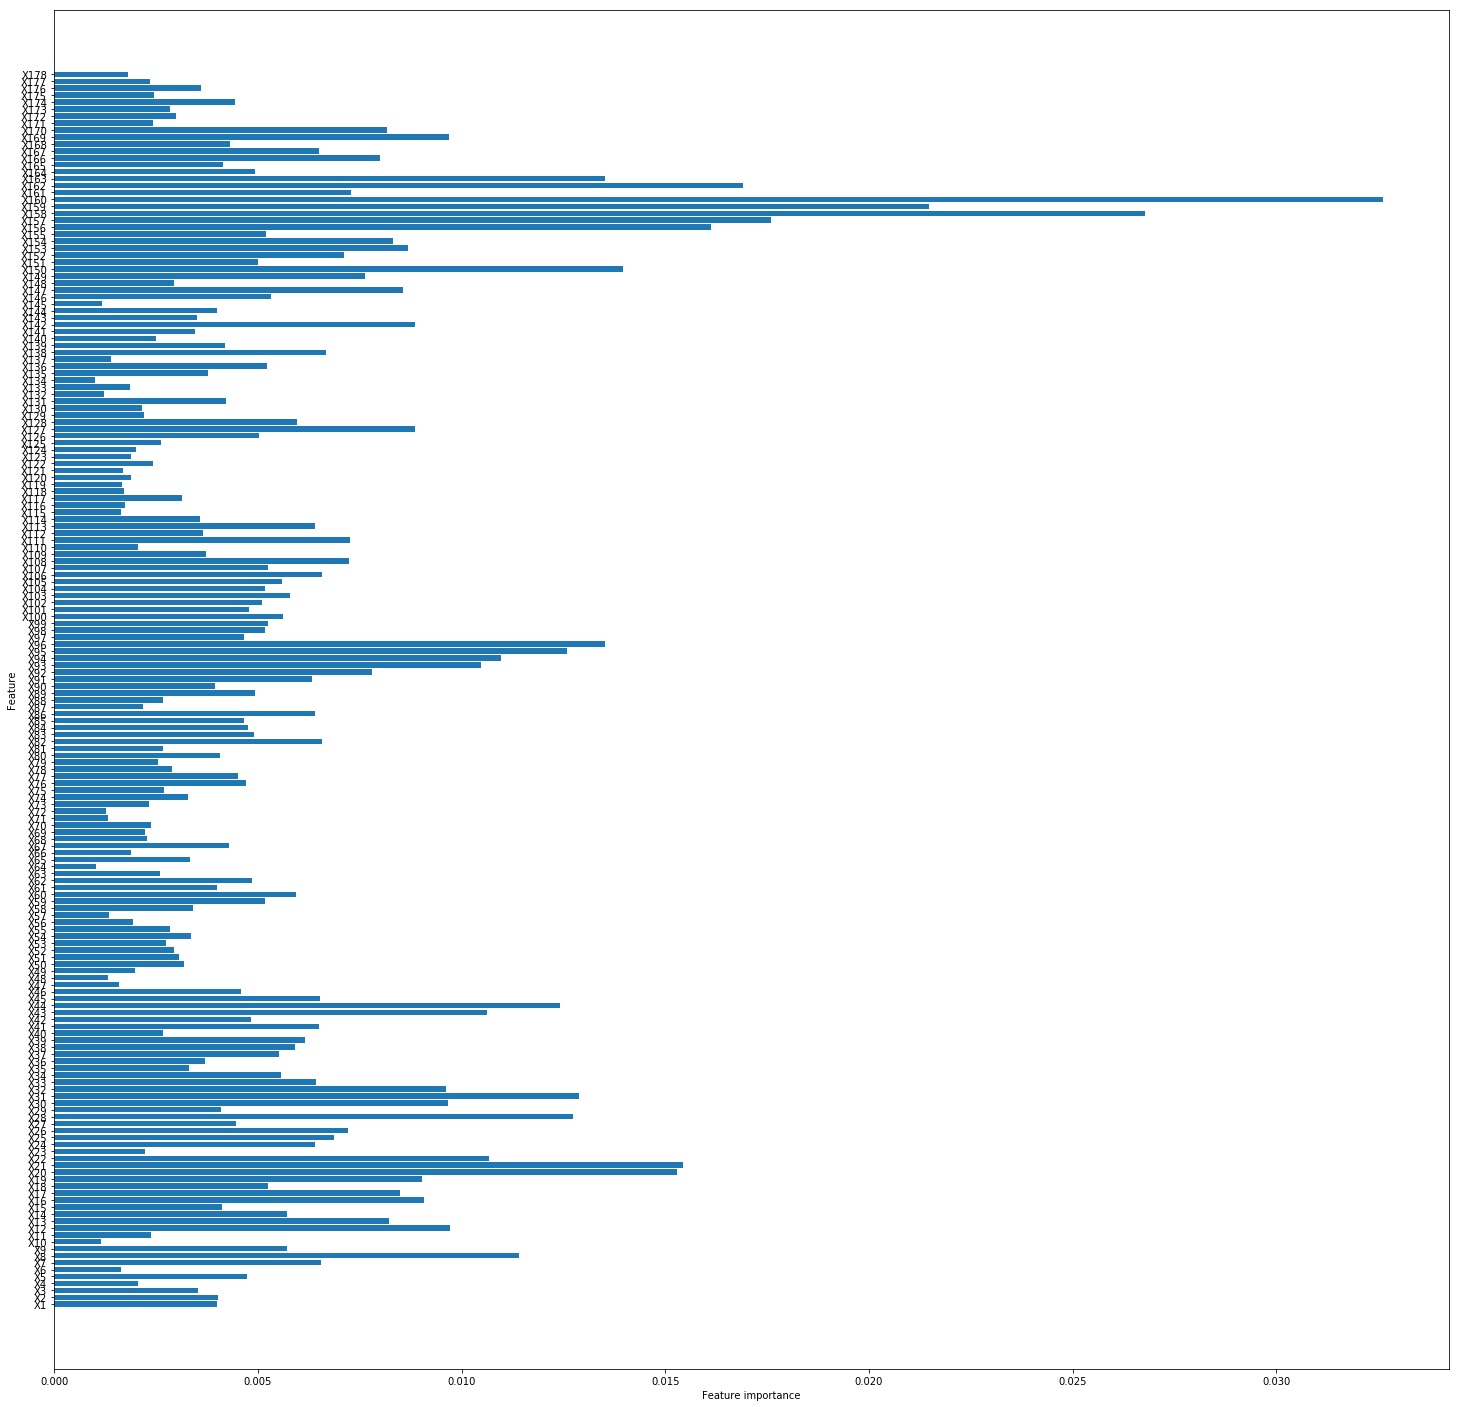

In [82]:
plot_feature_importances(grid_forest)

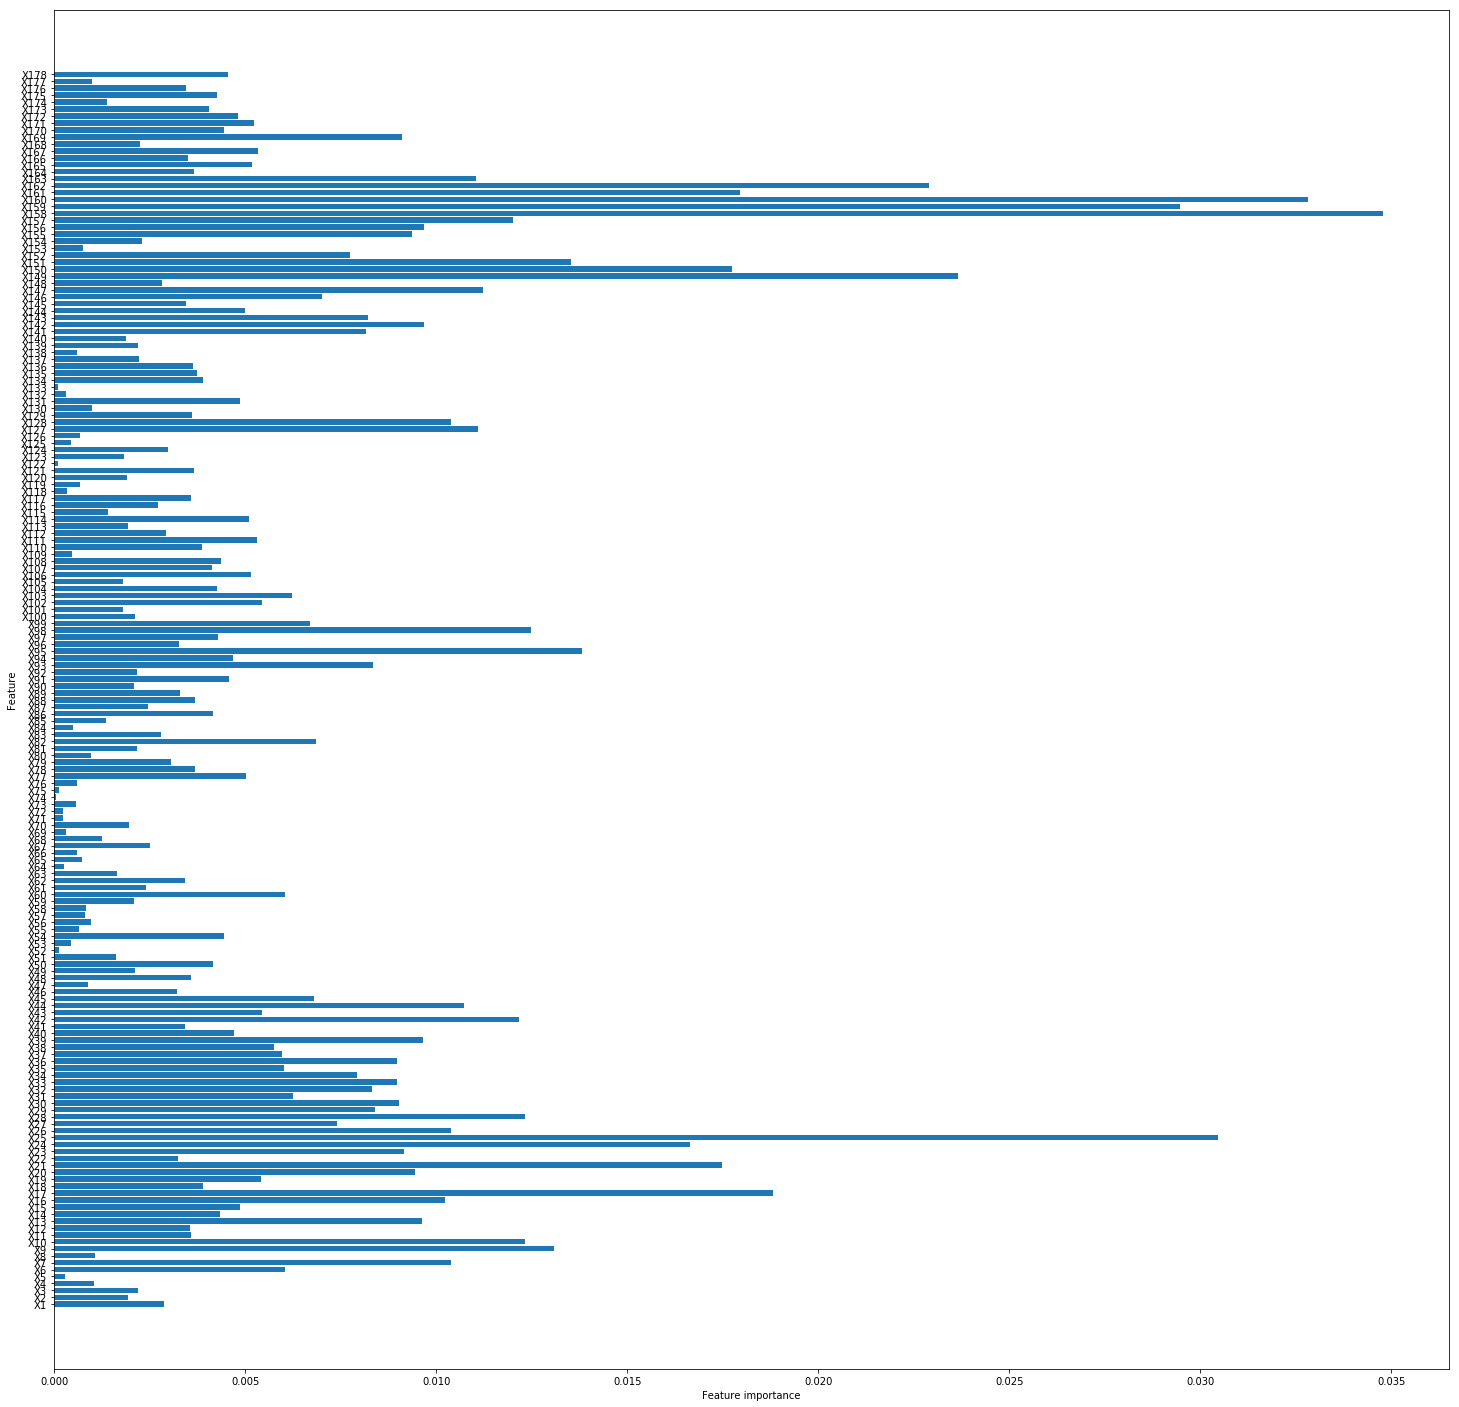

In [83]:
plot_feature_importances(forest)

In [84]:
forest.feature_importances_

array([2.87694635e-03, 1.92158453e-03, 2.18723331e-03, 1.05115444e-03,
       2.93487202e-04, 6.04912501e-03, 1.03840778e-02, 1.07129187e-03,
       1.30718531e-02, 1.23205862e-02, 3.58432284e-03, 3.55170373e-03,
       9.63719462e-03, 4.33697689e-03, 4.87294971e-03, 1.02203054e-02,
       1.88162600e-02, 3.89911843e-03, 5.41511926e-03, 9.43802611e-03,
       1.74739568e-02, 3.24030694e-03, 9.16790134e-03, 1.66542625e-02,
       3.04754911e-02, 1.03966776e-02, 7.38998136e-03, 1.23148342e-02,
       8.40225728e-03, 9.03496906e-03, 6.25757388e-03, 8.32108425e-03,
       8.98511674e-03, 7.93237890e-03, 6.00341232e-03, 8.98020013e-03,
       5.96300579e-03, 5.76446043e-03, 9.66216350e-03, 4.70474114e-03,
       3.42784520e-03, 1.21667275e-02, 5.43275572e-03, 1.07191457e-02,
       6.78883077e-03, 3.22223806e-03, 8.83285594e-04, 3.57054092e-03,
       2.10974931e-03, 4.15452904e-03, 1.60621491e-03, 1.24403078e-04,
       4.29531228e-04, 4.44313365e-03, 6.38194531e-04, 9.50351045e-04,
      

Let's try to look for multicollinearity within the model

In [85]:
accuracy_score(y_test, f_pred)

0.945391304347826

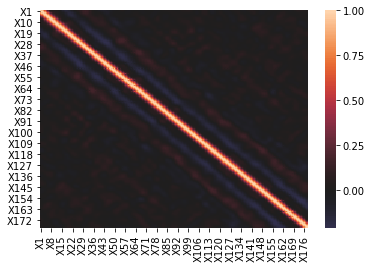

In [86]:
feat = df.loc[:, 'X1':'X178']

import seaborn as sns
sns.heatmap(feat.corr(), center=0);

Doesn't appear to have a great deal of multicollinearity within the model, PCA is likely superflous. Let's try SVC and XG BOOST TO see if it can surpass our random forest with grid search. 

In [87]:
from sklearn.svm import SVC
clf = SVC(kernel = 'rbf', random_state=0)
clf.fit(X_train, y_train)

C:\Users\xxtur\Anaconda3\envs\learn-env\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=0,
  shrinking=True, tol=0.001, verbose=False)

In [88]:
sv_pred =clf.predict(X_test)
accuracy_score(y_test, sv_pred)

0.9718260869565217

In [89]:
print(confusion_matrix(y_test, sv_pred))
print(classification_report(y_test, sv_pred))

[[2269   20]
 [  61  525]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2289
           1       0.96      0.90      0.93       586

   micro avg       0.97      0.97      0.97      2875
   macro avg       0.97      0.94      0.96      2875
weighted avg       0.97      0.97      0.97      2875



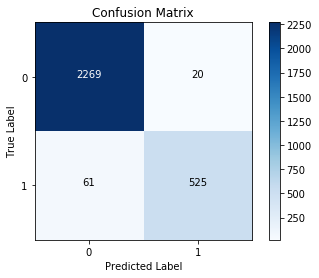

In [90]:
show_cf(y_test, sv_pred)

In [91]:
import xgboost as xgb

In [92]:
xg_clf = xgb.XGBClassifier()
xg_clf.fit(X_train, y_train)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
       colsample_bytree=1, gamma=0, learning_rate=0.1, max_delta_step=0,
       max_depth=3, min_child_weight=1, missing=None, n_estimators=100,
       n_jobs=1, nthread=None, objective='binary:logistic', random_state=0,
       reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
       silent=True, subsample=1)

In [93]:
xg_preds = xg_clf.predict(X_test)

In [94]:
print(accuracy_score(xg_preds, y_test))
print(confusion_matrix(y_test, xg_preds))
print(classification_report(y_test, xg_preds))

0.9652173913043478
[[2266   23]
 [  77  509]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2289
           1       0.96      0.87      0.91       586

   micro avg       0.97      0.97      0.97      2875
   macro avg       0.96      0.93      0.94      2875
weighted avg       0.97      0.97      0.96      2875



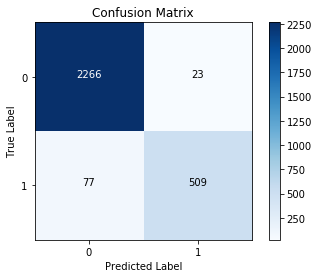

In [95]:
show_cf(y_test, xg_preds)

In [96]:
from sklearn.pipeline import Pipeline
pipe_lr = Pipeline([('scl', StandardScaler()),
                    ('clf', LogisticRegression(random_state=42))])

pipe_svm = Pipeline([('scl', StandardScaler()),
                    ('clf', SVC(random_state=42))])

pipe_rf = Pipeline([('scl', StandardScaler()),
                    ('clf', RandomForestClassifier(random_state=42))])

pipe_xg = Pipeline([('scl', StandardScaler()),
                    ('clf', xgb.XGBClassifier(random_state=42))])



# List of pipelines for ease of iteration
pipelines = [pipe_lr, pipe_svm, pipe_rf, pipe_xg]

In [97]:
pipe_dict = {0: 'Logistic Regression', 1: 'Support Vector Machine', 2: 'Random Forest', 3: 'XGBoost'}

for pipe in pipelines:
    pipe.fit(X_train, y_train)

for idx, val in enumerate(pipelines):
    print((pipe_dict[idx], val.score(X_test, y_test)))

C:\Users\xxtur\Anaconda3\envs\learn-env\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\xxtur\Anaconda3\envs\learn-env\lib\site-packages\sklearn\ensemble\forest.py:248: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


('Logistic Regression', 0.8114782608695652)
('Support Vector Machine', 0.9718260869565217)
('Random Forest', 0.9669565217391304)
('XGBoost', 0.9652173913043478)


Just in case, we'll try a Pipeline that incorporates PCA to see if it brings us better results.

In [99]:
# Construct pipeline
pipe_rf = Pipeline([('pca', PCA(n_components=50)),
            ('clf', RandomForestClassifier(random_state = 123))])

# Set grid search params
param_grid_forest = [ 
  {'clf__n_estimators': [120],
   'clf__criterion': ['entropy', 'gini'], 
   'clf__max_depth': [4, 5, 6],  
   'clf__min_samples_leaf':[0.05 ,0.1, 0.2],  
   'clf__min_samples_split':[0.05 ,0.1, 0.2]
  }
]

# Construct grid search
gs_rf = GridSearchCV(estimator=pipe_rf,
            param_grid=param_grid_forest,
            scoring='accuracy',
            cv=3, verbose=2, return_train_score = True)

# Fit using grid search
gs_rf.fit(X_train, y_train)

# Best accuracy
print('Best accuracy: %.3f' % gs_rf.best_score_)

# Best params
print('\nBest params:\n', gs_rf.best_params_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.05, clf__n_estimators=120 


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV]  clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.05, clf__n_estimators=120, total=   2.8s
[CV] clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.05, clf__n_estimators=120 


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.8s remaining:    0.0s


[CV]  clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.05, clf__n_estimators=120, total=   1.9s
[CV] clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.05, clf__n_estimators=120 
[CV]  clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.05, clf__n_estimators=120, total=   1.8s
[CV] clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.1, clf__n_estimators=120 
[CV]  clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.1, clf__n_estimators=120, total=   1.8s
[CV] clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.1, clf__n_estimators=120 
[CV]  clf__criterion=entropy, clf__max_depth=4, clf__min_samples_leaf=0.05, clf__min_samples_split=0.1, clf__n_estimators=120, total=   1.9s
[CV] clf__criterion=entropy, clf__max_depth=4, clf__min

...

[CV]  clf__criterion=gini, clf__max_depth=4, clf__min_samples_leaf=0.1, clf__min_samples_split=0.1, clf__n_estimators=120, total=   1.0s
[CV] clf__criterion=gini, clf__max_depth=4, clf__min_samples_leaf=0.1, clf__min_samples_split=0.2, clf__n_estimators=120 
[CV]  clf__criterion=gini, clf__max_depth=4, clf__min_samples_leaf=0.1, clf__min_samples_split=0.2, clf__n_estimators=120, total=   1.0s
[CV] clf__criterion=gini, clf__max_depth=4, clf__min_samples_leaf=0.1, clf__min_samples_split=0.2, clf__n_estimators=120 
[CV]  clf__criterion=gini, clf__max_depth=4, clf__min_samples_leaf=0.1, clf__min_samples_split=0.2, clf__n_estimators=120, total=   1.0s
[CV] clf__criterion=gini, clf__max_depth=4, clf__min_samples_leaf=0.1, clf__min_samples_split=0.2, clf__n_estimators=120 
[CV]  clf__criterion=gini, clf__max_depth=4, clf__min_samples_leaf=0.1, clf__min_samples_split=0.2, clf__n_estimators=120, total=   1.0s
[CV] clf__criterion=gini, clf__max_depth=4, clf__min_samples_leaf=0.2, clf__min_sample

[CV]  clf__criterion=gini, clf__max_depth=5, clf__min_samples_leaf=0.2, clf__min_samples_split=0.05, clf__n_estimators=120, total=   0.6s
[CV] clf__criterion=gini, clf__max_depth=5, clf__min_samples_leaf=0.2, clf__min_samples_split=0.05, clf__n_estimators=120 
[CV]  clf__criterion=gini, clf__max_depth=5, clf__min_samples_leaf=0.2, clf__min_samples_split=0.05, clf__n_estimators=120, total=   0.6s
[CV] clf__criterion=gini, clf__max_depth=5, clf__min_samples_leaf=0.2, clf__min_samples_split=0.1, clf__n_estimators=120 
[CV]  clf__criterion=gini, clf__max_depth=5, clf__min_samples_leaf=0.2, clf__min_samples_split=0.1, clf__n_estimators=120, total=   0.6s
[CV] clf__criterion=gini, clf__max_depth=5, clf__min_samples_leaf=0.2, clf__min_samples_split=0.1, clf__n_estimators=120 
[CV]  clf__criterion=gini, clf__max_depth=5, clf__min_samples_leaf=0.2, clf__min_samples_split=0.1, clf__n_estimators=120, total=   0.7s
[CV] clf__criterion=gini, clf__max_depth=5, clf__min_samples_leaf=0.2, clf__min_sam

[CV]  clf__criterion=gini, clf__max_depth=6, clf__min_samples_leaf=0.2, clf__min_samples_split=0.2, clf__n_estimators=120, total=   0.7s
[CV] clf__criterion=gini, clf__max_depth=6, clf__min_samples_leaf=0.2, clf__min_samples_split=0.2, clf__n_estimators=120 
[CV]  clf__criterion=gini, clf__max_depth=6, clf__min_samples_leaf=0.2, clf__min_samples_split=0.2, clf__n_estimators=120, total=   0.7s
[CV] clf__criterion=gini, clf__max_depth=6, clf__min_samples_leaf=0.2, clf__min_samples_split=0.2, clf__n_estimators=120 
[CV]  clf__criterion=gini, clf__max_depth=6, clf__min_samples_leaf=0.2, clf__min_samples_split=0.2, clf__n_estimators=120, total=   0.6s


[Parallel(n_jobs=1)]: Done 162 out of 162 | elapsed:  3.8min finished


Best accuracy: 0.937

Best params:
 {'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_leaf': 0.05, 'clf__min_samples_split': 0.05, 'clf__n_estimators': 120}


In [100]:
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'scl', 'pca', 'svm', 'scl__copy', 'scl__feature_range', 'pca__copy', 'pca__iterated_power', 'pca__n_components', 'pca__random_state', 'pca__svd_solver', 'pca__tol', 'pca__whiten', 'svm__C', 'svm__cache_size', 'svm__class_weight', 'svm__coef0', 'svm__decision_function_shape', 'svm__degree', 'svm__gamma', 'svm__kernel', 'svm__max_iter', 'svm__probability', 'svm__random_state', 'svm__shrinking', 'svm__tol', 'svm__verbose'])

With our finalized model, let's look to make our machine a bit  more sensitive and tune the degree of certainty that our classifier needs to declare something a seizure. To play it safer, we want to identify as many seizures as possible so let's make a custom set of predictions that predicts a seizure even when the likelihood is much lower than 50%. 

In [114]:
grid_forest.predict_proba(X_test)

array([[0.12172872, 0.87827128],
       [1.        , 0.        ],
       [0.19596387, 0.80403613],
       ...,
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ]])

In [128]:
len(grid_forest.predict_proba(X_test))

2875

In [117]:
grid_forest.predict_proba(X_test)[0][0]

0.12172871572871573

In [124]:
len(g_f_pred)

2875

In [157]:
custom_pred = []
for i in range(0, len(g_f_pred)):
    if grid_forest.predict_proba(X_test)[i][1]>.2:
        custom_pred.append(1)
    else:
        custom_pred.append(0)
    print("LET'S GO PEPEGA ZOOOOOOOM", i)


LET'S GO PEPEGA ZOOOOOOOM 0
LET'S GO PEPEGA ZOOOOOOOM 1
LET'S GO PEPEGA ZOOOOOOOM 2
LET'S GO PEPEGA ZOOOOOOOM 3
LET'S GO PEPEGA ZOOOOOOOM 4
LET'S GO PEPEGA ZOOOOOOOM 5
LET'S GO PEPEGA ZOOOOOOOM 6
LET'S GO PEPEGA ZOOOOOOOM 7
LET'S GO PEPEGA ZOOOOOOOM 8
LET'S GO PEPEGA ZOOOOOOOM 9
LET'S GO PEPEGA ZOOOOOOOM 10
LET'S GO PEPEGA ZOOOOOOOM 11
LET'S GO PEPEGA ZOOOOOOOM 12
LET'S GO PEPEGA ZOOOOOOOM 13
LET'S GO PEPEGA ZOOOOOOOM 14
LET'S GO PEPEGA ZOOOOOOOM 15
LET'S GO PEPEGA ZOOOOOOOM 16
LET'S GO PEPEGA ZOOOOOOOM 17
LET'S GO PEPEGA ZOOOOOOOM 18
LET'S GO PEPEGA ZOOOOOOOM 19
LET'S GO PEPEGA ZOOOOOOOM 20
LET'S GO PEPEGA ZOOOOOOOM 21
LET'S GO PEPEGA ZOOOOOOOM 22
LET'S GO PEPEGA ZOOOOOOOM 23
LET'S GO PEPEGA ZOOOOOOOM 24
LET'S GO PEPEGA ZOOOOOOOM 25
LET'S GO PEPEGA ZOOOOOOOM 26
LET'S GO PEPEGA ZOOOOOOOM 27
LET'S GO PEPEGA ZOOOOOOOM 28
LET'S GO PEPEGA ZOOOOOOOM 29
LET'S GO PEPEGA ZOOOOOOOM 30
LET'S GO PEPEGA ZOOOOOOOM 31
LET'S GO PEPEGA ZOOOOOOOM 32
LET'S GO PEPEGA ZOOOOOOOM 33
LET'S GO PEPEGA ZOOOOOOO

LET'S GO PEPEGA ZOOOOOOOM 279
LET'S GO PEPEGA ZOOOOOOOM 280
LET'S GO PEPEGA ZOOOOOOOM 281
LET'S GO PEPEGA ZOOOOOOOM 282
LET'S GO PEPEGA ZOOOOOOOM 283
LET'S GO PEPEGA ZOOOOOOOM 284
LET'S GO PEPEGA ZOOOOOOOM 285
LET'S GO PEPEGA ZOOOOOOOM 286
LET'S GO PEPEGA ZOOOOOOOM 287
LET'S GO PEPEGA ZOOOOOOOM 288
LET'S GO PEPEGA ZOOOOOOOM 289
LET'S GO PEPEGA ZOOOOOOOM 290
LET'S GO PEPEGA ZOOOOOOOM 291
LET'S GO PEPEGA ZOOOOOOOM 292
LET'S GO PEPEGA ZOOOOOOOM 293
LET'S GO PEPEGA ZOOOOOOOM 294
LET'S GO PEPEGA ZOOOOOOOM 295
LET'S GO PEPEGA ZOOOOOOOM 296
LET'S GO PEPEGA ZOOOOOOOM 297
LET'S GO PEPEGA ZOOOOOOOM 298
LET'S GO PEPEGA ZOOOOOOOM 299
LET'S GO PEPEGA ZOOOOOOOM 300
LET'S GO PEPEGA ZOOOOOOOM 301
LET'S GO PEPEGA ZOOOOOOOM 302
LET'S GO PEPEGA ZOOOOOOOM 303
LET'S GO PEPEGA ZOOOOOOOM 304
LET'S GO PEPEGA ZOOOOOOOM 305
LET'S GO PEPEGA ZOOOOOOOM 306
LET'S GO PEPEGA ZOOOOOOOM 307
LET'S GO PEPEGA ZOOOOOOOM 308
LET'S GO PEPEGA ZOOOOOOOM 309
LET'S GO PEPEGA ZOOOOOOOM 310
LET'S GO PEPEGA ZOOOOOOOM 311
LET'S GO P

LET'S GO PEPEGA ZOOOOOOOM 555
LET'S GO PEPEGA ZOOOOOOOM 556
LET'S GO PEPEGA ZOOOOOOOM 557
LET'S GO PEPEGA ZOOOOOOOM 558
LET'S GO PEPEGA ZOOOOOOOM 559
LET'S GO PEPEGA ZOOOOOOOM 560
LET'S GO PEPEGA ZOOOOOOOM 561
LET'S GO PEPEGA ZOOOOOOOM 562
LET'S GO PEPEGA ZOOOOOOOM 563
LET'S GO PEPEGA ZOOOOOOOM 564
LET'S GO PEPEGA ZOOOOOOOM 565
LET'S GO PEPEGA ZOOOOOOOM 566
LET'S GO PEPEGA ZOOOOOOOM 567
LET'S GO PEPEGA ZOOOOOOOM 568
LET'S GO PEPEGA ZOOOOOOOM 569
LET'S GO PEPEGA ZOOOOOOOM 570
LET'S GO PEPEGA ZOOOOOOOM 571
LET'S GO PEPEGA ZOOOOOOOM 572
LET'S GO PEPEGA ZOOOOOOOM 573
LET'S GO PEPEGA ZOOOOOOOM 574
LET'S GO PEPEGA ZOOOOOOOM 575
LET'S GO PEPEGA ZOOOOOOOM 576
LET'S GO PEPEGA ZOOOOOOOM 577
LET'S GO PEPEGA ZOOOOOOOM 578
LET'S GO PEPEGA ZOOOOOOOM 579
LET'S GO PEPEGA ZOOOOOOOM 580
LET'S GO PEPEGA ZOOOOOOOM 581
LET'S GO PEPEGA ZOOOOOOOM 582
LET'S GO PEPEGA ZOOOOOOOM 583
LET'S GO PEPEGA ZOOOOOOOM 584
LET'S GO PEPEGA ZOOOOOOOM 585
LET'S GO PEPEGA ZOOOOOOOM 586
LET'S GO PEPEGA ZOOOOOOOM 587
LET'S GO P

LET'S GO PEPEGA ZOOOOOOOM 830
LET'S GO PEPEGA ZOOOOOOOM 831
LET'S GO PEPEGA ZOOOOOOOM 832
LET'S GO PEPEGA ZOOOOOOOM 833
LET'S GO PEPEGA ZOOOOOOOM 834
LET'S GO PEPEGA ZOOOOOOOM 835
LET'S GO PEPEGA ZOOOOOOOM 836
LET'S GO PEPEGA ZOOOOOOOM 837
LET'S GO PEPEGA ZOOOOOOOM 838
LET'S GO PEPEGA ZOOOOOOOM 839
LET'S GO PEPEGA ZOOOOOOOM 840
LET'S GO PEPEGA ZOOOOOOOM 841
LET'S GO PEPEGA ZOOOOOOOM 842
LET'S GO PEPEGA ZOOOOOOOM 843
LET'S GO PEPEGA ZOOOOOOOM 844
LET'S GO PEPEGA ZOOOOOOOM 845
LET'S GO PEPEGA ZOOOOOOOM 846
LET'S GO PEPEGA ZOOOOOOOM 847
LET'S GO PEPEGA ZOOOOOOOM 848
LET'S GO PEPEGA ZOOOOOOOM 849
LET'S GO PEPEGA ZOOOOOOOM 850
LET'S GO PEPEGA ZOOOOOOOM 851
LET'S GO PEPEGA ZOOOOOOOM 852
LET'S GO PEPEGA ZOOOOOOOM 853
LET'S GO PEPEGA ZOOOOOOOM 854
LET'S GO PEPEGA ZOOOOOOOM 855
LET'S GO PEPEGA ZOOOOOOOM 856
LET'S GO PEPEGA ZOOOOOOOM 857
LET'S GO PEPEGA ZOOOOOOOM 858
LET'S GO PEPEGA ZOOOOOOOM 859
LET'S GO PEPEGA ZOOOOOOOM 860
LET'S GO PEPEGA ZOOOOOOOM 861
LET'S GO PEPEGA ZOOOOOOOM 862
LET'S GO P

LET'S GO PEPEGA ZOOOOOOOM 1101
LET'S GO PEPEGA ZOOOOOOOM 1102
LET'S GO PEPEGA ZOOOOOOOM 1103
LET'S GO PEPEGA ZOOOOOOOM 1104
LET'S GO PEPEGA ZOOOOOOOM 1105
LET'S GO PEPEGA ZOOOOOOOM 1106
LET'S GO PEPEGA ZOOOOOOOM 1107
LET'S GO PEPEGA ZOOOOOOOM 1108
LET'S GO PEPEGA ZOOOOOOOM 1109
LET'S GO PEPEGA ZOOOOOOOM 1110
LET'S GO PEPEGA ZOOOOOOOM 1111
LET'S GO PEPEGA ZOOOOOOOM 1112
LET'S GO PEPEGA ZOOOOOOOM 1113
LET'S GO PEPEGA ZOOOOOOOM 1114
LET'S GO PEPEGA ZOOOOOOOM 1115
LET'S GO PEPEGA ZOOOOOOOM 1116
LET'S GO PEPEGA ZOOOOOOOM 1117
LET'S GO PEPEGA ZOOOOOOOM 1118
LET'S GO PEPEGA ZOOOOOOOM 1119
LET'S GO PEPEGA ZOOOOOOOM 1120
LET'S GO PEPEGA ZOOOOOOOM 1121
LET'S GO PEPEGA ZOOOOOOOM 1122
LET'S GO PEPEGA ZOOOOOOOM 1123
LET'S GO PEPEGA ZOOOOOOOM 1124
LET'S GO PEPEGA ZOOOOOOOM 1125
LET'S GO PEPEGA ZOOOOOOOM 1126
LET'S GO PEPEGA ZOOOOOOOM 1127
LET'S GO PEPEGA ZOOOOOOOM 1128
LET'S GO PEPEGA ZOOOOOOOM 1129
LET'S GO PEPEGA ZOOOOOOOM 1130
LET'S GO PEPEGA ZOOOOOOOM 1131
LET'S GO PEPEGA ZOOOOOOOM 1132
LET'S GO

...

LET'S GO PEPEGA ZOOOOOOOM 1632
LET'S GO PEPEGA ZOOOOOOOM 1633
LET'S GO PEPEGA ZOOOOOOOM 1634
LET'S GO PEPEGA ZOOOOOOOM 1635
LET'S GO PEPEGA ZOOOOOOOM 1636
LET'S GO PEPEGA ZOOOOOOOM 1637
LET'S GO PEPEGA ZOOOOOOOM 1638
LET'S GO PEPEGA ZOOOOOOOM 1639
LET'S GO PEPEGA ZOOOOOOOM 1640
LET'S GO PEPEGA ZOOOOOOOM 1641
LET'S GO PEPEGA ZOOOOOOOM 1642
LET'S GO PEPEGA ZOOOOOOOM 1643
LET'S GO PEPEGA ZOOOOOOOM 1644
LET'S GO PEPEGA ZOOOOOOOM 1645
LET'S GO PEPEGA ZOOOOOOOM 1646
LET'S GO PEPEGA ZOOOOOOOM 1647
LET'S GO PEPEGA ZOOOOOOOM 1648
LET'S GO PEPEGA ZOOOOOOOM 1649
LET'S GO PEPEGA ZOOOOOOOM 1650
LET'S GO PEPEGA ZOOOOOOOM 1651
LET'S GO PEPEGA ZOOOOOOOM 1652
LET'S GO PEPEGA ZOOOOOOOM 1653
LET'S GO PEPEGA ZOOOOOOOM 1654
LET'S GO PEPEGA ZOOOOOOOM 1655
LET'S GO PEPEGA ZOOOOOOOM 1656
LET'S GO PEPEGA ZOOOOOOOM 1657
LET'S GO PEPEGA ZOOOOOOOM 1658
LET'S GO PEPEGA ZOOOOOOOM 1659
LET'S GO PEPEGA ZOOOOOOOM 1660
LET'S GO PEPEGA ZOOOOOOOM 1661
LET'S GO PEPEGA ZOOOOOOOM 1662
LET'S GO PEPEGA ZOOOOOOOM 1663
LET'S GO

LET'S GO PEPEGA ZOOOOOOOM 1897
LET'S GO PEPEGA ZOOOOOOOM 1898
LET'S GO PEPEGA ZOOOOOOOM 1899
LET'S GO PEPEGA ZOOOOOOOM 1900
LET'S GO PEPEGA ZOOOOOOOM 1901
LET'S GO PEPEGA ZOOOOOOOM 1902
LET'S GO PEPEGA ZOOOOOOOM 1903
LET'S GO PEPEGA ZOOOOOOOM 1904
LET'S GO PEPEGA ZOOOOOOOM 1905
LET'S GO PEPEGA ZOOOOOOOM 1906
LET'S GO PEPEGA ZOOOOOOOM 1907
LET'S GO PEPEGA ZOOOOOOOM 1908
LET'S GO PEPEGA ZOOOOOOOM 1909
LET'S GO PEPEGA ZOOOOOOOM 1910
LET'S GO PEPEGA ZOOOOOOOM 1911
LET'S GO PEPEGA ZOOOOOOOM 1912
LET'S GO PEPEGA ZOOOOOOOM 1913
LET'S GO PEPEGA ZOOOOOOOM 1914
LET'S GO PEPEGA ZOOOOOOOM 1915
LET'S GO PEPEGA ZOOOOOOOM 1916
LET'S GO PEPEGA ZOOOOOOOM 1917
LET'S GO PEPEGA ZOOOOOOOM 1918
LET'S GO PEPEGA ZOOOOOOOM 1919
LET'S GO PEPEGA ZOOOOOOOM 1920
LET'S GO PEPEGA ZOOOOOOOM 1921
LET'S GO PEPEGA ZOOOOOOOM 1922
LET'S GO PEPEGA ZOOOOOOOM 1923
LET'S GO PEPEGA ZOOOOOOOM 1924
LET'S GO PEPEGA ZOOOOOOOM 1925
LET'S GO PEPEGA ZOOOOOOOM 1926
LET'S GO PEPEGA ZOOOOOOOM 1927
LET'S GO PEPEGA ZOOOOOOOM 1928
LET'S GO

LET'S GO PEPEGA ZOOOOOOOM 2165
LET'S GO PEPEGA ZOOOOOOOM 2166
LET'S GO PEPEGA ZOOOOOOOM 2167
LET'S GO PEPEGA ZOOOOOOOM 2168
LET'S GO PEPEGA ZOOOOOOOM 2169
LET'S GO PEPEGA ZOOOOOOOM 2170
LET'S GO PEPEGA ZOOOOOOOM 2171
LET'S GO PEPEGA ZOOOOOOOM 2172
LET'S GO PEPEGA ZOOOOOOOM 2173
LET'S GO PEPEGA ZOOOOOOOM 2174
LET'S GO PEPEGA ZOOOOOOOM 2175
LET'S GO PEPEGA ZOOOOOOOM 2176
LET'S GO PEPEGA ZOOOOOOOM 2177
LET'S GO PEPEGA ZOOOOOOOM 2178
LET'S GO PEPEGA ZOOOOOOOM 2179
LET'S GO PEPEGA ZOOOOOOOM 2180
LET'S GO PEPEGA ZOOOOOOOM 2181
LET'S GO PEPEGA ZOOOOOOOM 2182
LET'S GO PEPEGA ZOOOOOOOM 2183
LET'S GO PEPEGA ZOOOOOOOM 2184
LET'S GO PEPEGA ZOOOOOOOM 2185
LET'S GO PEPEGA ZOOOOOOOM 2186
LET'S GO PEPEGA ZOOOOOOOM 2187
LET'S GO PEPEGA ZOOOOOOOM 2188
LET'S GO PEPEGA ZOOOOOOOM 2189
LET'S GO PEPEGA ZOOOOOOOM 2190
LET'S GO PEPEGA ZOOOOOOOM 2191
LET'S GO PEPEGA ZOOOOOOOM 2192
LET'S GO PEPEGA ZOOOOOOOM 2193
LET'S GO PEPEGA ZOOOOOOOM 2194
LET'S GO PEPEGA ZOOOOOOOM 2195
LET'S GO PEPEGA ZOOOOOOOM 2196
LET'S GO

LET'S GO PEPEGA ZOOOOOOOM 2431
LET'S GO PEPEGA ZOOOOOOOM 2432
LET'S GO PEPEGA ZOOOOOOOM 2433
LET'S GO PEPEGA ZOOOOOOOM 2434
LET'S GO PEPEGA ZOOOOOOOM 2435
LET'S GO PEPEGA ZOOOOOOOM 2436
LET'S GO PEPEGA ZOOOOOOOM 2437
LET'S GO PEPEGA ZOOOOOOOM 2438
LET'S GO PEPEGA ZOOOOOOOM 2439
LET'S GO PEPEGA ZOOOOOOOM 2440
LET'S GO PEPEGA ZOOOOOOOM 2441
LET'S GO PEPEGA ZOOOOOOOM 2442
LET'S GO PEPEGA ZOOOOOOOM 2443
LET'S GO PEPEGA ZOOOOOOOM 2444
LET'S GO PEPEGA ZOOOOOOOM 2445
LET'S GO PEPEGA ZOOOOOOOM 2446
LET'S GO PEPEGA ZOOOOOOOM 2447
LET'S GO PEPEGA ZOOOOOOOM 2448
LET'S GO PEPEGA ZOOOOOOOM 2449
LET'S GO PEPEGA ZOOOOOOOM 2450
LET'S GO PEPEGA ZOOOOOOOM 2451
LET'S GO PEPEGA ZOOOOOOOM 2452
LET'S GO PEPEGA ZOOOOOOOM 2453
LET'S GO PEPEGA ZOOOOOOOM 2454
LET'S GO PEPEGA ZOOOOOOOM 2455
LET'S GO PEPEGA ZOOOOOOOM 2456
LET'S GO PEPEGA ZOOOOOOOM 2457
LET'S GO PEPEGA ZOOOOOOOM 2458
LET'S GO PEPEGA ZOOOOOOOM 2459
LET'S GO PEPEGA ZOOOOOOOM 2460
LET'S GO PEPEGA ZOOOOOOOM 2461
LET'S GO PEPEGA ZOOOOOOOM 2462
LET'S GO

LET'S GO PEPEGA ZOOOOOOOM 2696
LET'S GO PEPEGA ZOOOOOOOM 2697
LET'S GO PEPEGA ZOOOOOOOM 2698
LET'S GO PEPEGA ZOOOOOOOM 2699
LET'S GO PEPEGA ZOOOOOOOM 2700
LET'S GO PEPEGA ZOOOOOOOM 2701
LET'S GO PEPEGA ZOOOOOOOM 2702
LET'S GO PEPEGA ZOOOOOOOM 2703
LET'S GO PEPEGA ZOOOOOOOM 2704
LET'S GO PEPEGA ZOOOOOOOM 2705
LET'S GO PEPEGA ZOOOOOOOM 2706
LET'S GO PEPEGA ZOOOOOOOM 2707
LET'S GO PEPEGA ZOOOOOOOM 2708
LET'S GO PEPEGA ZOOOOOOOM 2709
LET'S GO PEPEGA ZOOOOOOOM 2710
LET'S GO PEPEGA ZOOOOOOOM 2711
LET'S GO PEPEGA ZOOOOOOOM 2712
LET'S GO PEPEGA ZOOOOOOOM 2713
LET'S GO PEPEGA ZOOOOOOOM 2714
LET'S GO PEPEGA ZOOOOOOOM 2715
LET'S GO PEPEGA ZOOOOOOOM 2716
LET'S GO PEPEGA ZOOOOOOOM 2717
LET'S GO PEPEGA ZOOOOOOOM 2718
LET'S GO PEPEGA ZOOOOOOOM 2719
LET'S GO PEPEGA ZOOOOOOOM 2720
LET'S GO PEPEGA ZOOOOOOOM 2721
LET'S GO PEPEGA ZOOOOOOOM 2722
LET'S GO PEPEGA ZOOOOOOOM 2723
LET'S GO PEPEGA ZOOOOOOOM 2724
LET'S GO PEPEGA ZOOOOOOOM 2725
LET'S GO PEPEGA ZOOOOOOOM 2726
LET'S GO PEPEGA ZOOOOOOOM 2727
LET'S GO

In [158]:
len(custom_pred)

2875

In [159]:
print(accuracy_score(custom_pred, y_test))
print(confusion_matrix(y_test, custom_pred))
print(classification_report(y_test, custom_pred))

0.9412173913043478
[[2127  162]
 [   7  579]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      2289
           1       0.78      0.99      0.87       586

   micro avg       0.94      0.94      0.94      2875
   macro avg       0.89      0.96      0.92      2875
weighted avg       0.95      0.94      0.94      2875



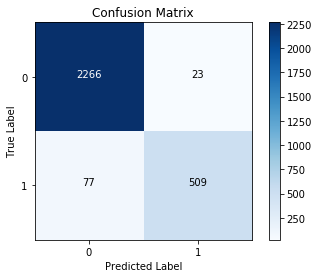

In [160]:
show_cf(y_test, xg_preds)